In [19]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report , accuracy_score , confusion_matrix

In [10]:
data = pd.read_csv('/home/spandan/Documents/sumago/Traffic-Prediction/dataset/feature_engineered_data.csv')
data.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,days_of_week,month,day,year,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,291.97,0.0,0.0,1,5097,12,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
1,293.23,0.0,0.0,1,4887,13,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
2,294.31,0.0,0.0,1,5337,14,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
3,295.17,0.0,0.0,1,5692,15,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False
4,295.13,0.0,0.0,1,6137,16,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,False


### for classification , we will make a congestion column with low , high , critical , and medium traffic

In [11]:
data['congestion_level'] = pd.qcut(data['traffic_volume'] , q = 4 , labels=['low' , 'medium' , 'high' , 'critical'])

In [12]:
data['congestion_level'].value_counts()

congestion_level
high        12053
medium      12049
low         12045
critical    12031
Name: count, dtype: int64

In [13]:
data.head(30)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,days_of_week,month,day,year,...,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm,congestion_level
0,291.97,0.0,0.0,1,5097,12,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,critical
1,293.23,0.0,0.0,1,4887,13,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,high
2,294.31,0.0,0.0,1,5337,14,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,critical
3,295.17,0.0,0.0,1,5692,15,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,critical
4,295.13,0.0,0.0,1,6137,16,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,critical
5,293.66,0.0,0.0,20,4623,18,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,high
6,290.65,0.0,0.0,20,3591,19,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,high
7,288.19,0.0,0.0,20,2898,20,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,medium
8,287.10,0.0,0.0,1,2637,21,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,medium
9,286.25,0.0,0.0,1,1777,22,2,10,3,2012,...,False,False,False,False,False,False,False,False,False,medium


In [14]:
x = data.drop(columns=['traffic_volume' , 'congestion_level'])
y = data['congestion_level']

In [15]:
split_idx = int(len(data) * 0.8)

x_train = x.iloc[:split_idx]
x_test = x.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [17]:
rfModel = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfModel.fit(x_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [18]:
rfPrediction = rfModel.predict(x_test)

In [20]:
print(f'Accuracy : {accuracy_score(y_test , rfPrediction)}')

Accuracy : 0.9267330842673308


In [21]:
print(classification_report(y_test , rfPrediction))

              precision    recall  f1-score   support

    critical       0.94      0.92      0.93      2365
        high       0.88      0.89      0.88      2463
         low       0.98      0.97      0.97      2378
      medium       0.92      0.93      0.92      2430

    accuracy                           0.93      9636
   macro avg       0.93      0.93      0.93      9636
weighted avg       0.93      0.93      0.93      9636



In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
confusionMatrix = confusion_matrix(y_test , rfPrediction)

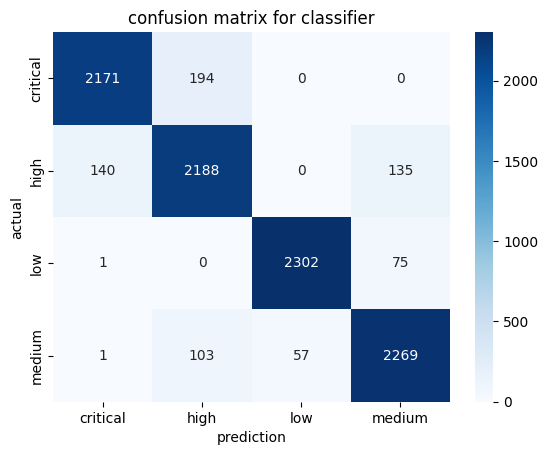

In [26]:
plt.Figure(figsize=(6,6))
sns.heatmap(
    confusionMatrix,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels=rfModel.classes_,
    yticklabels=rfModel.classes_
)

plt.xlabel('prediction')
plt.ylabel('actual')
plt.title('confusion matrix for classifier')
plt.show()

so the model makes mistakes only when something like , it says high instead of critical.